In [1]:
!git clone https://github.com/MartinsOluwatobi/CV-Learning-Journal-.git
import sys
import os

# Check if the folder exists to avoid errors
repo_path = '/content/CV-Learning-Journal-/Faster RCNN'
if repo_path not in sys.path:
    sys.path.append(repo_path)


Cloning into 'CV-Learning-Journal-'...
remote: Enumerating objects: 1780, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 1780 (delta 20), reused 24 (delta 11), pack-reused 1744 (from 1)
Receiving objects: 100% (1780/1780), 395.54 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (877/877), done.


In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision.transforms as transforms 
from torch.utils.data import Dataset, DataLoader
import torch
import cv2 as cv
import matplotlib.pyplot as plt
from FasterRCNN import FasterRCNN
from LossFunction import Encode_rpn_target_and_label,rpn_loss,final_rcnn_loss, Encode_final_target_label,box_coordinate
from Backbone import FeatureExtractor
from RegionProposalNetwork import RegionProposalNetwork
from RoiPooling import RoIPooling
from Metrics import LabelAccuracy,BoxAccuracy
import cv2 as cv

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Colab Notebooks/data'

In [5]:
annotation,Images = [],[]
for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith('.xml'):
            sample_dir = os.path.join(root,file)
            try:
               xml_root = ET.parse(sample_dir).getroot()
            except ET.ParseError as e:
               continue
            annotation.append(sample_dir)
        if file.endswith(('.jpg','.png', '.jpeg')):
            sample_dir = os.path.join(root,file)
            Images.append(sample_dir)
sorted_annotation = sorted(annotation)
sorted_Images  = sorted(Images)
annotaion_train, annotation_test, Image_train, Image_test = train_test_split(sorted_annotation, sorted_Images[:-2], test_size= 0.2,  random_state=42, shuffle = True)
splits = { 'Train': (annotaion_train, Image_train),
          'Val':(annotation_test, Image_test)}


In [ ]:
class CustomDataset(Dataset):
    def __init__(self,data, image_size = (224,224), augment= False ):
        self.data = data
        if augment:
            self.transform = transforms.Compose([
                                                 transforms.Resize((224,224)),
                                                 transforms.RandomHorizontalFlip(),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
        else:
            self.transform = transforms.Compose([
                                                 transforms.Resize((224,224)),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
        self.label_map = {
            'with_mask':1,
            'without_mask':0,
            'mask_weared_incorrect':1}
    
    def __getitem__(self,idx):
        img_path, labels, boxes = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        init_img_width, init_img_height = img.size 
        width_scale = 224/ init_img_width
        height_scale = 224/ init_img_height
        img = self.transform(img)
        scaled_boxes = [(x1*width_scale,y1*height_scale, x2*width_scale,y2 * height_scale)  
               for x1,y1,x2,y2 in boxes]
        
        label = [self.label_map[l] for l in labels]
        return img, {'boxes': torch.tensor(scaled_boxes, dtype= torch.float32), 'target': torch.tensor(label, dtype= torch.long)}
    
    def __len__(self):
        return len(self.data)
        

def DataExtraction(dir):
    row = []
    xml_files_path = os.path.join(dir,'Annotation')
    xml_files = [f for f in os.listdir(xml_files_path) if f.endswith('.xml')]
    for xml in xml_files:
        xml = os.path.join(xml_files_path, xml) 
        try:
            root = ET.parse(xml).getroot()
        except ET.ParseError as e:
            continue
        filename = root.find('filename').text
        img = f'{str(dir)}/Image/{filename}'
        labels = [obj.find('name').text for obj in root.findall('object')]
        boundingbox = [(int(obj.find('bndbox').find('xmin').text),
                    int(obj.find('bndbox').find('ymin').text),
                    int(obj.find('bndbox').find('xmax').text),
                    int(obj.find('bndbox').find('ymax').text)) for obj in root.findall('object') ]
        row.append([img,labels, boundingbox])
    return row 

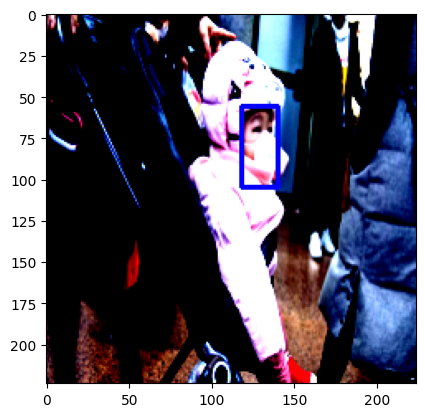

In [7]:
dir_train = file_path + '/Train'
dir_test = file_path + '/Val'
raw_data_train = DataExtraction(dir_train)
raw_data_test = DataExtraction(dir_test)
data_train = CustomDataset(raw_data_train, augment= True)
data_test = CustomDataset(raw_data_test, augment= False)
a = next(iter(data_test))
sample_image= a[0].permute(1,2,0).cpu().numpy()
sample_image= (np.clip(sample_image,0,1)*255).astype(np.uint8)
sample_image = sample_image.copy()

boxes = a[1]['boxes']
if len(boxes) > 0:
    face_masks =[(int(t[0]),int(t[1]),int(t[2]),int(t[3])) for t in boxes]
    for x1,y1,x2,y2 in face_masks:         
        cv.rectangle(sample_image,(x1,y1),(x2,y2),(0,0,255),2)
plt.imshow(sample_image)

In [ ]:
def collate_fn(batch):
    """
    batch: list of (image_tensor, target_dict) tuples
    Returns images stacked as a tensor, targets left as a list of dicts.
    """
    images  = torch.stack([item[0] for item in batch])  # (B, C, H, W) — safe, all same size
    targets = [item[1] for item in batch]               # list of dicts — NOT stacked
    return images, targets


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataloader = DataLoader(data_train,batch_size=16,shuffle = True, collate_fn= collate_fn )
test_dataloader = DataLoader(data_test, batch_size= 16, collate_fn=collate_fn)
epochs = 50

model = FasterRCNN(num_classes=2, image_shape=(224,224)).to(device)
for param in model.feature_extractor.parameters():
    param.requires_grad = False
optimizer = torch.optim.SGD(model.parameters(),
                            lr = 0.001)

for epoch in range(epochs):
  model.train()
  epoch_loss = 0
  train_box_acc, train_label_acc = 0,0
  test_box_acc, test_label_acc = 0,0
  epoch_test_loss = 0
  for images,target_dict in train_dataloader:
      images = images.to(device)
      optimizer.zero_grad()
      pred_cls, pred_delta,proposal_boxes,pred_rpn_delta, pred_rpn_cls, anchors, batch_idx= model(images)
      ground_truth = [t['boxes'].to(device) for t in target_dict]
      gt_labels = [t['target'].to(device) for t in target_dict]
      batch_rpn_label_list, batch_rpn_target_list = [],[]
      batch_size = images.shape[0]
      for i in range(batch_size):
          mask = batch_idx==i
          anchor = anchors[mask]
          gt_box = ground_truth[i]
          labels, target = Encode_rpn_target_and_label(anchor,gt_box)
          batch_rpn_label_list.append(labels)
          batch_rpn_target_list.append(target)
      batch_rpn_label = torch.cat(batch_rpn_label_list)
      batch_rpn_target = torch.cat(batch_rpn_target_list)
      rpn_cls_loss, rpn_delta_loss = rpn_loss(pred_rpn_cls,pred_rpn_delta,batch_rpn_label,batch_rpn_target)


      batch_final_label, batch_final_delta = [], []
      batch_pred_cls,   batch_pred_delta   = [], []   
      batch_sampled_proposal =[]
      reg_loss, cls_loss = 0,0

      # build a per-image offset into the flat proposal tensor
      offsets = [0]
      for i in range(batch_size - 1):
          offsets.append(offsets[-1] + (batch_idx == i).sum().item())

      for i in range(batch_size):
          mask = batch_idx == i
          img_proposal = proposal_boxes[mask]
          idx, final_label, final_target = Encode_final_target_label(
              img_proposal, ground_truth[i], gt_labels[i]
          )
          batch_final_label.append(final_label.detach())
          batch_final_delta.append(final_target.detach())

          # slice model outputs using the same idx, offset into flat tensor
          global_idx = idx + offsets[i]
          batch_pred_cls.append(pred_cls[global_idx])
          batch_pred_delta.append(pred_delta[global_idx])
          batch_sampled_proposal.append(img_proposal[idx].detach())
          

      batch_final_labels  = torch.cat(batch_final_label)
      batch_final_deltas  = torch.cat(batch_final_delta)
      batch_pred_cls   = torch.cat(batch_pred_cls)    
      batch_pred_delta   = torch.cat(batch_pred_delta)  
      sampled_proposals = torch.cat(batch_sampled_proposal)  

      final_cls_loss, final_reg_loss = final_rcnn_loss(batch_pred_cls, batch_pred_delta, batch_final_labels, batch_final_deltas)
      train_label_acc += float(LabelAccuracy(batch_pred_cls.detach(), batch_final_labels))
      train_box_acc += float(BoxAccuracy(batch_pred_delta.detach(), batch_final_deltas, sampled_proposals))
      
      loss = rpn_cls_loss + rpn_delta_loss + final_cls_loss +final_reg_loss
      reg_loss += final_reg_loss.item()
      cls_loss += final_cls_loss.item()
      epoch_loss += loss.item()
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step() 
  reg_loss /= len(train_dataloader)
  cls_loss /= len(train_dataloader)
  epoch_loss /= len(train_dataloader)
  train_label_acc/= len(train_dataloader)
  train_box_acc/= len(train_dataloader)
 


  model.eval()
  epoch_test_loss = 0
  test_label_acc, test_box_acc = 0,0
  with torch.no_grad():
    for images, target_dict in test_dataloader:
        images = images.to(device)
        test_pred_cls, test_pred_delta,test_proposal_boxes,test_rpn_delta, test_rpn_cls, test_anchors, test_batch_idx= model(images)
        ground_truth = [t['boxes'].to(device) for t in target_dict]
        gt_labels = [t['target'].to(device) for t in target_dict]

        batch_rpn_label_list, batch_rpn_target_list = [],[]
        batch_size = images.shape[0]
        for i in range(batch_size):
            mask = test_batch_idx==i
            test_anchor = test_anchors[mask]
            gt_box = ground_truth[i]
            labels, target = Encode_rpn_target_and_label(test_anchor,gt_box)
            batch_rpn_label_list.append(labels)
            batch_rpn_target_list.append(target)
        batch_rpn_label = torch.cat(batch_rpn_label_list)
        batch_rpn_target = torch.cat(batch_rpn_target_list)
        rpn_cls_loss_test, rpn_delta_loss_test = rpn_loss(test_rpn_cls,test_rpn_delta,batch_rpn_label,batch_rpn_target)

       
        batch_final_label_test, batch_final_delta_test = [], []
        batch_test_pred_cls,   batch_test_pred_delta   = [], []   
        batch_proposal_boxes = []

        # build a per-image offset into the flat proposal tensor
        offsets = [0]
        for i in range(batch_size - 1):
            offsets.append(offsets[-1] + (test_batch_idx == i).sum().item())

        for i in range(batch_size):
            mask = test_batch_idx == i
            img_proposal = test_proposal_boxes[mask]
            idx, final_label, final_delta = Encode_final_target_label(
                img_proposal, ground_truth[i], gt_labels[i]
            )
            batch_final_label_test.append(final_label.detach())
            batch_final_delta_test.append(final_delta.detach())

            # slice model outputs using the same idx, offset into flat tensor
            global_idx = idx + offsets[i]
            batch_test_pred_cls.append(test_pred_cls[global_idx])
            batch_test_pred_delta.append(test_pred_delta[global_idx])
            batch_proposal_boxes.append(img_proposal[idx].detach())

        final_labels_test  = torch.cat(batch_final_label_test)
        final_deltas_test  = torch.cat(batch_final_delta_test)
        batch_test_pred_cls   = torch.cat(batch_test_pred_cls)    
        batch_test_pred_delta   = torch.cat(batch_test_pred_delta)    
        sampled_batch_proposal = torch.cat(batch_proposal_boxes)

        final_cls_loss_test, final_reg_loss_test = final_rcnn_loss(batch_test_pred_cls, batch_test_pred_delta, final_labels_test, final_deltas_test)
        loss_test = final_cls_loss_test + final_reg_loss_test + rpn_cls_loss_test + rpn_delta_loss_test
        test_label_acc += float(LabelAccuracy(batch_test_pred_cls.detach(), final_labels_test))
        test_box_acc += float(BoxAccuracy(batch_test_pred_delta.detach(), final_deltas_test, sampled_batch_proposal))
        epoch_test_loss += loss_test.item()
            
    
    epoch_test_loss /= len(test_dataloader) 
    test_label_acc/= len(test_dataloader)
    test_box_acc/= len(test_dataloader)
  
  if epoch % 2 == 0:
    print('-'*50)
    print(f'Model info at Epoch {epoch}')
    print (f'The training loss is : {epoch_loss}')
    print (f'The training regression loss is : {reg_loss}')
    print (f'The training classification loss is : {cls_loss}')
    print(f'The training label accuracy is :{train_label_acc}; box accuracy is {train_box_acc}')
    print(f'The test loss is : {epoch_test_loss}')
    print(f'The test label accuracy is :{test_label_acc}; box accuracy is {test_box_acc}')
  del loss, rpn_cls_loss, rpn_delta_loss, final_cls_loss, final_reg_loss
  del batch_pred_cls, batch_pred_delta, batch_final_labels, batch_final_deltas
  del sampled_proposals, batch_rpn_label, batch_rpn_target

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 244MB/s]


--------------------------------------------------
Model info at Epoch 0
The training loss is : 1.896410346031189
The training regression loss is : 0.0
The training classification loss is : 0.01417904537777568
The training label accuracy is :0.5798351199127907; box accuracy is 0.027801957934401756
The test loss is : 1.7981335033069958
The test label accuracy is :0.8355944925103306; box accuracy is 0.02739967778325081
--------------------------------------------------
Model info at Epoch 2
The training loss is : 1.5929057792175647
The training regression loss is : 0.0008569735773774081
The training classification loss is : 0.008653692727865175
The training label accuracy is :0.9968295784883722; box accuracy is 0.02794594317674637
The test loss is : 1.540044210173867
The test label accuracy is :0.9987813145661157; box accuracy is 0.026962608776309273
--------------------------------------------------
Model info at Epoch 4
The training loss is : 1.4255304613778756
The training regression 

KeyboardInterrupt: 

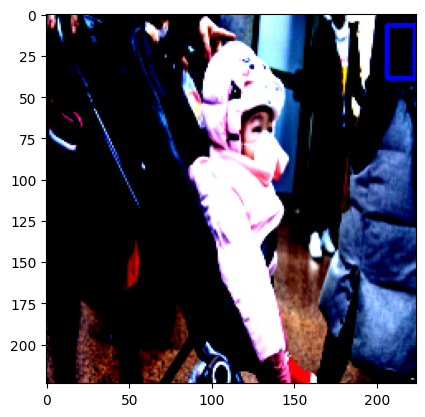

In [10]:
input = a[0].to(device).unsqueeze(0)
pred_cls, pred_delta,proposal_boxes,pred_rpn_delta, pred_rpn_cls, anchors, batch_idx= model(input)
pred_prob = torch.softmax(pred_cls,dim = 1) 
score, label= torch.max(pred_prob[:,1:], dim =1)
pos = torch.argmax(score)
best_cls_proposal = proposal_boxes[pos].unsqueeze(0)
best_delta = final_delta[pos].unsqueeze(0)
obj_cordinate = box_coordinate(best_delta,best_cls_proposal).squeeze(0 )
input_image = input.squeeze(0).permute(1,2,0).cpu().numpy()
input_image= (np.clip(input_image,0,1)*255).astype(np.uint8)
input_image = input_image.copy()

boxes = obj_cordinate.detach().cpu().numpy()
if len(boxes) == 4:
    #face_masks =[(int(t[0]),int(t[1]),int(t[2]),int(t[3])) for t in boxes]
    x1,y1,x2,y2 =  boxes.tolist()
    x1 = int(np.clip(x1,0,223))
    x2 = int(np.clip(x2,0,223))
    y1 = int(np.clip(y1,0,223))
    y2 = int(np.clip(y2,0,223))
    cv.rectangle(input_image,(x1,y1),(x2,y2),(0,0,255),2)
plt.imshow(input_image)

In [11]:
x2

223